# Day 3 · 客户 ABC 分层 · 海豚生 🐬

> **德邦经营方向 · 第 3 天练习**  
> 目标：找出 TOP 客户，做 ABC 分层，回答「流失一个 A 类客户损失多少」

---

## 今天你要学会

| 技能 | 对应德邦场景 |
|------|-------------|
| 按客户汇总营收 | 谁是大客户？ |
| `cumsum()` 累计占比 | 80/20 法则（帕累托） |
| ABC 分层 | A=核心客户，B=潜力，C=长尾 |
| 经营结论 | 该锁谁、该防谁流失 |

## 什么是 ABC 分层？

| 等级 | 规则（累计营收占比） | 经营策略 |
|------|---------------------|---------|
| **A 类** | 前 80% 营收 | 专人维护、合同续签、专属服务 |
| **B 类** | 80% ~ 95% | 培育升级，争取变成 A |
| **C 类** | 后 5% | 标准化服务，控制成本 |

## 对标案例

`泰坦尼克号.ipynb` 里用 `groupby` 做分组统计 — 今天换成按 **customer_name** 分组。

**文件名：** `Day3_Customer_ABC.ipynb`

In [8]:
import pandas as pd

df = pd.read_csv("data/orders.csv")
print(f"共 {len(df)} 条运单，{df['customer_name'].nunique()} 个客户")
df[["order_id", "customer_name", "revenue", "region"]].head(5)

共 150 条运单，14 个客户


,order_id,customer_name,revenue,region
0,ORD2024110001,华为供应链,212.79,华东
1,ORD2025010002,美的物流,2985.46,西南
2,ORD2024020003,陈师傅,2205.41,华北
3,ORD2024120004,刘店主,593.35,华东
4,ORD2024120005,华为供应链,1138.58,华东


---
## 第 1 步：按客户汇总营收

In [2]:
customer_stats = df.groupby("customer_name").agg(
    总营收=("revenue", "sum"),
    单量=("order_id", "count"),
    平均单笔=("revenue", "mean"),
).reset_index()

# 按营收从高到低排序
customer_stats = customer_stats.sort_values("总营收", ascending=False).reset_index(drop=True)
customer_stats["平均单笔"] = customer_stats["平均单笔"].round(2)

print("TOP 5 客户：")
customer_stats.head(5)

TOP 5 客户：


,customer_name,总营收,单量,平均单笔
0,华为供应链,36718.75,15,2447.92
1,美的物流,36103.71,10,3610.37
2,陈师傅,33430.31,9,3714.48
3,王商户,31391.16,11,2853.74
4,张先生,28666.66,12,2388.89


---
## 第 2 步：算累计占比 + ABC 分层 ⭐

**核心逻辑：**
1. 从高到低累加每个客户的营收
2. 看累计到多少百分比
3. ≤80% → A，80%~95% → B，>95% → C

In [9]:
total_revenue = customer_stats["总营收"].sum()

customer_stats["累计营收"] = customer_stats["总营收"].cumsum()
customer_stats["累计占比(%)"] = (customer_stats["累计营收"] / total_revenue * 100).round(1)

def classify_abc(cum_pct):
    if cum_pct <= 80:
        return "A"
    elif cum_pct <= 95:
        return "B"
    return "C"

customer_stats["ABC"] = customer_stats["累计占比(%)"].apply(classify_abc)

customer_stats[["customer_name", "总营收", "单量", "累计占比(%)", "ABC"]]

,customer_name,总营收,单量,累计占比(%),ABC
0,华为供应链,36718.75,15,11.2,A
1,美的物流,36103.71,10,22.2,A
2,陈师傅,33430.31,9,32.4,A
3,王商户,31391.16,11,42.0,A
4,张先生,28666.66,12,50.7,A
5,刘店主,28542.10,12,59.4,A
6,格力物流,28158.00,12,68.0,A
7,顺丰合作,24520.88,16,75.5,A
8,李女士,18918.57,8,81.2,B
9,京东仓配,18056.18,11,86.7,B


In [4]:
# ABC 各层汇总
abc_summary = customer_stats.groupby("ABC").agg(
    客户数=("customer_name", "count"),
    总营收=("总营收", "sum"),
).reset_index()
abc_summary["营收占比(%)"] = (abc_summary["总营收"] / total_revenue * 100).round(1)

print("=" * 45)
print("  客户 ABC 分层汇总 · 海豚生")
print("=" * 45)
for _, row in abc_summary.sort_values("ABC").iterrows():
    print(f"  {row['ABC']} 类: {int(row['客户数'])} 个客户，贡献营收 {row['营收占比(%)']}%")
print("=" * 45)
abc_summary

  客户 ABC 分层汇总 · 海豚生
  A 类: 8 个客户，贡献营收 75.5%
  B 类: 3 个客户，贡献营收 16.8%
  C 类: 3 个客户，贡献营收 7.8%


,ABC,客户数,总营收,营收占比(%)
0,A,8,247531.57,75.5
1,B,3,54995.59,16.8
2,C,3,25470.45,7.8


---
## 第 3 步：「流失一个 A 类客户」损失多少？ 💰

这是德邦经营分析里**最有含金量**的问题之一。

In [5]:
# 营收 TOP 1 客户（最大的 A 类）
top1 = customer_stats.iloc[0]
a_class = customer_stats[customer_stats["ABC"] == "A"]

print(f"TOP 1 客户: {top1['customer_name']}")
print(f"  贡献营收: {top1['总营收']:,.2f} 元（占总量 {top1['总营收']/total_revenue*100:.1f}%）")
print(f"  若流失，相当于损失 {top1['总营收']/10000:.1f} 万营收")
print()
print(f"A 类客户共 {len(a_class)} 个，合计占营收 {a_class['总营收'].sum()/total_revenue*100:.1f}%")
print("→ 保住 A 类 = 保住大部分基本盘")

TOP 1 客户: 华为供应链
  贡献营收: 36,718.75 元（占总量 11.2%）
  若流失，相当于损失 3.7 万营收

A 类客户共 8 个，合计占营收 75.5%
→ 保住 A 类 = 保住大部分基本盘


---
## 第 4 步：ABC 饼图（可选）

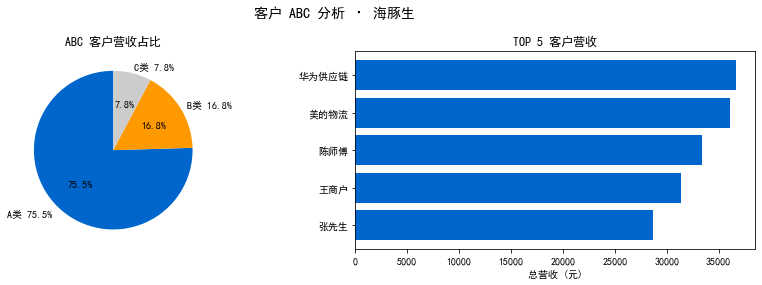

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

colors = {"A": "#0066CC", "B": "#FF9900", "C": "#CCCCCC"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：ABC 营收占比
axes[0].pie(
    abc_summary["总营收"],
    labels=[f"{r['ABC']}类 {r['营收占比(%)']}%" for _, r in abc_summary.iterrows()],
    colors=[colors[a] for a in abc_summary["ABC"]],
    autopct="%1.1f%%", startangle=90,
)
axes[0].set_title("ABC 客户营收占比")

# 右：TOP5 客户柱状图
top5 = customer_stats.head(5)
axes[1].barh(top5["customer_name"], top5["总营收"], color="#0066CC")
axes[1].set_xlabel("总营收 (元)")
axes[1].set_title("TOP 5 客户营收")
axes[1].invert_yaxis()

plt.suptitle("客户 ABC 分析 · 海豚生", fontsize=14)
plt.tight_layout()
plt.show()

---
## 第 5 步：写经营结论 ✏️

In [10]:
# 第 5 步：根据 ABC 结果生成经营结论
# 先取出前 3 大客户、A 类汇总和最大客户
ranked_customers = customer_stats.head(3)
a_class = customer_stats[customer_stats["ABC"] == "A"]
top1 = customer_stats.iloc[0]

my_report = f"""
【数据发现】
- TOP 3 客户：{ranked_customers.iloc[0]['customer_name']}、{ranked_customers.iloc[1]['customer_name']}、{ranked_customers.iloc[2]['customer_name']}
- A 类客户 {len(a_class)} 个，贡献 {a_class['总营收'].sum()/total_revenue*100:.1f}% 营收
- 最大客户 {top1['customer_name']} 单独占 {top1['总营收']/total_revenue*100:.1f}%

【经营含义】
客户集中度较高，A 类客户是业务基本盘；如果其中一个核心客户流失，营收影响会非常明显。

【下周动作 — 客户经营 2 条建议】
1. 对 A 类客户做重点维护，优先安排合同续签、服务回访和专属沟通。
2. 对 B 类客户中单量较多或平均单笔较高的客户，主动推进增量业务和深度合作。
"""

print(my_report)


【数据发现】
- TOP 3 客户：华为供应链、美的物流、陈师傅
- A 类客户 8 个，贡献 75.5% 营收
- 最大客户 华为供应链 单独占 11.2%

【经营含义】
客户集中度较高，A 类客户是业务基本盘；如果其中一个核心客户流失，营收影响会非常明显。

【下周动作 — 客户经营 2 条建议】
1. 对 A 类客户做重点维护，优先安排合同续签、服务回访和专属沟通。
2. 对 B 类客户中单量较多或平均单笔较高的客户，主动推进增量业务和深度合作。



---
## 🎯 进阶小练习

1. 找出 **B 类客户**里单量最多的是谁？（升级潜力）
2. 哪些 A 类客户有 **客诉**？（`df` 里 `is_complaint=1` 的客户）
3. 算 A 类客户的 **平均毛利率** vs C 类客户

<details>
<summary>💡 参考答案</summary>

```python
# 1. B 类单量最多
b = customer_stats[customer_stats["ABC"] == "B"]
print(b.sort_values("单量", ascending=False).head(1))

# 2. A 类中有客诉的客户
a_names = customer_stats[customer_stats["ABC"] == "A"]["customer_name"]
complaints = df[(df["customer_name"].isin(a_names)) & (df["is_complaint"] == 1)]
print(complaints.groupby("customer_name").size())

# 3. 各 ABC 毛利率
df2 = df.merge(customer_stats[["customer_name", "ABC"]], on="customer_name")
df2["毛利"] = df2["revenue"] - df2["cost"]
print(df2.groupby("ABC").apply(lambda x: (x["毛利"].sum()/x["revenue"].sum()*100).round(2)))
```
</details>

---

## ✅ Day 3 完成标准

- [ ] 客户汇总表 + ABC 分层跑通
- [ ] 能说出 TOP 3 客户和 A 类营收占比
- [ ] 算了「流失 TOP1 客户」的损失
- [ ] 写了 2 条客户经营建议

**预期结果参考：**
| 客户 | 营收 | ABC |
|------|------|-----|
| 华为供应链 | ~3.7 万 | A |
| 美的物流 | ~3.6 万 | A |
| 陈师傅 | ~3.3 万 | A |
| A 类合计 | **8 个客户，75.5% 营收** | |

**明天 Day 4：** 可视化汇报 — 区域柱状图 + 产品毛利率对比 📊

In [11]:
# 进阶小练习：直接计算结果

# 1. B 类客户里单量最多的是谁？
b_class = customer_stats[customer_stats["ABC"] == "B"]
print("B 类客户中单量最多的是：")
print(b_class.sort_values("单量", ascending=False).head(1)[["customer_name", "单量", "总营收"]])

# 2. A 类客户中有客诉的客户
try:
    a_names = customer_stats[customer_stats["ABC"] == "A"]["customer_name"]
    complaints = df[(df["customer_name"].isin(a_names)) & (df["is_complaint"] == 1)]
    print("\nA 类客户中有客诉的客户：")
    print(complaints.groupby("customer_name").size())
except KeyError:
    print("\n当前数据没有 is_complaint 字段，无法判断客诉客户。")

# 3. A 类客户 vs C 类客户的平均毛利率
try:
    df2 = df.merge(customer_stats[["customer_name", "ABC"]], on="customer_name")
    df2["毛利"] = df2["revenue"] - df2["cost"]
    margin_by_abc = (
        df2.groupby("ABC")
        .apply(lambda x: (x["毛利"].sum() / x["revenue"].sum() * 100).round(2))
    )
    print("\n各 ABC 类别平均毛利率：")
    print(margin_by_abc)
except KeyError:
    print("\n当前数据没有 cost 字段，无法计算毛利率。")

B 类客户中单量最多的是：
   customer_name  单量       总营收
10          海尔智家  13  18020.84

A 类客户中有客诉的客户：
customer_name
刘店主      2
华为供应链    4
格力物流     4
王商户      3
美的物流     2
顺丰合作     1
dtype: int64

各 ABC 类别平均毛利率：
ABC
A    26.91
B    28.43
C    28.38
dtype: float64


C:\Users\32669\AppData\Local\Temp/ipykernel_29652/433774549.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2.groupby("ABC")
